In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data Explotation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #Visualization
import seaborn as sns #Advanced Visualization
%matplotlib inline

# Data modelling libraries
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score

In [97]:
#Loading data 
df = pd.read_csv("marketing_campaign.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [98]:
print("Rows, Columns:", df.shape)
print("Columns:", df.columns.tolist())
display(df.info())
display(df.describe(include="all"))

Rows, Columns: (2240, 29)
Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teen

None

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,31/08/2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [80]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Customer_Tenure         0
dtype: int64

In [99]:
#drop columns not needed to determine price
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

In [76]:
print(df['Dt_Customer'].astype(str).unique()[:20])

['04/09/2012' '08/03/2014' '21/08/2013' '10/02/2014' '19/01/2014'
 '09/09/2013' '13/11/2012' '08/05/2013' '06/06/2013' '13/03/2014'
 '15/11/2013' '10/10/2012' '24/11/2012' '24/12/2012' '31/08/2012'
 '28/03/2013' '03/11/2012' '08/08/2012' '06/01/2013' '23/12/2012']


In [100]:
# Date parsing 

df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d/%m/%Y',
    errors='coerce'
)

In [101]:
df['Customer_Tenure'] = (
    pd.Timestamp.today() - df['Dt_Customer']
).dt.days

In [102]:
# Drop original date
df = df.drop(columns=['Dt_Customer'])

In [103]:
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,58,635,88,...,4,7,0,0,0,0,0,0,1,5013
1,2174,1954,Graduation,Single,46344.0,1,1,38,11,1,...,2,5,0,0,0,0,0,0,0,4463


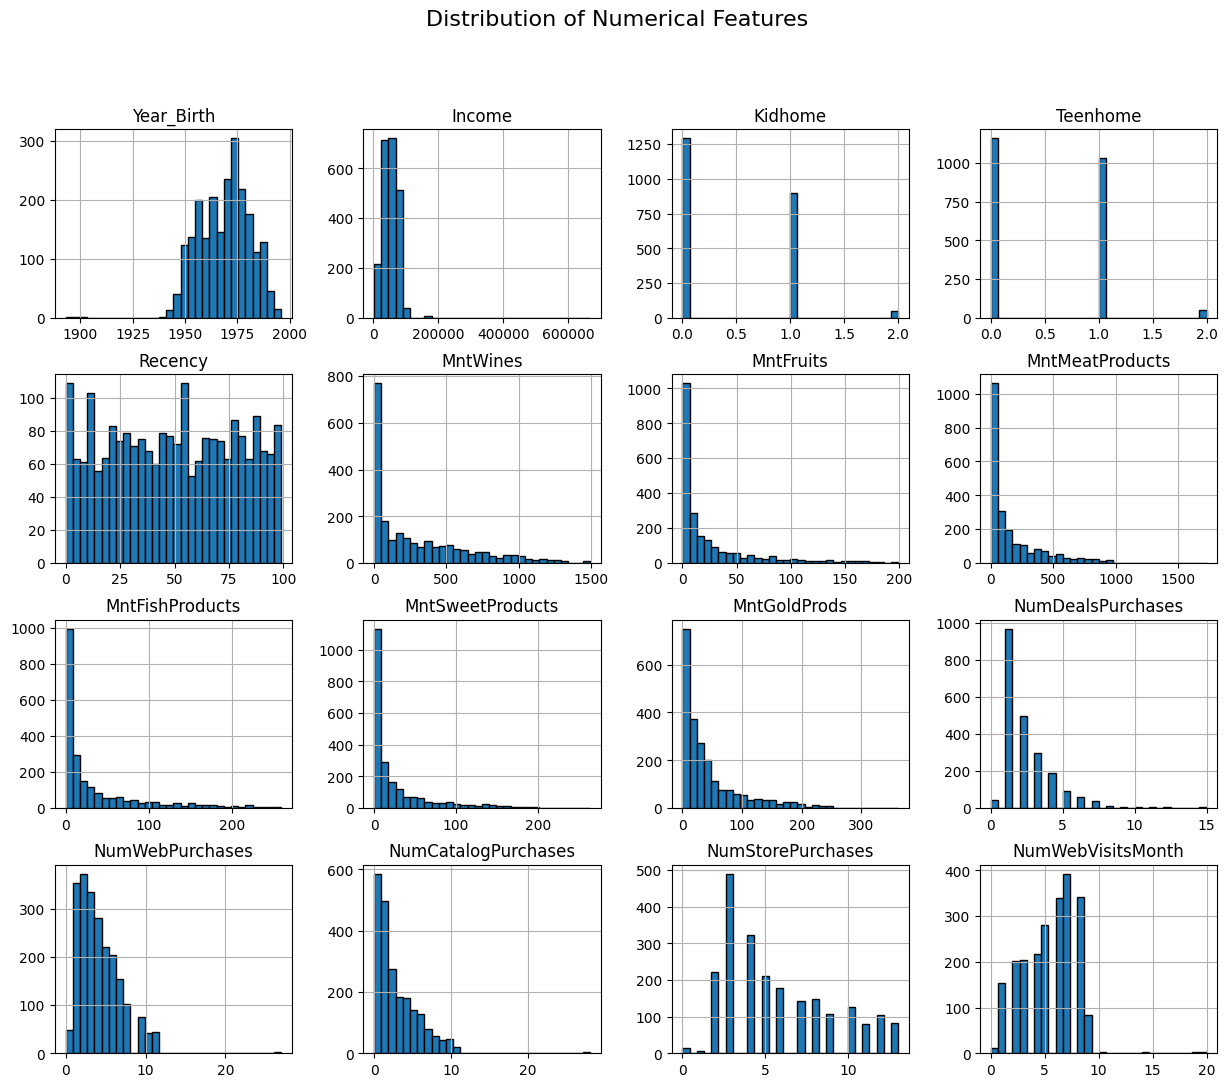

In [83]:

#numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

numeric_cols = ["Year_Birth", "Income", "Kidhome", "Teenhome", "Recency",
                "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
                "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
                "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
                "NumWebVisitsMonth"]

# Histograms
df[numeric_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

In [104]:
# Fill missing values
df['Income'] = df['Income'].fillna(df['Income'].median())

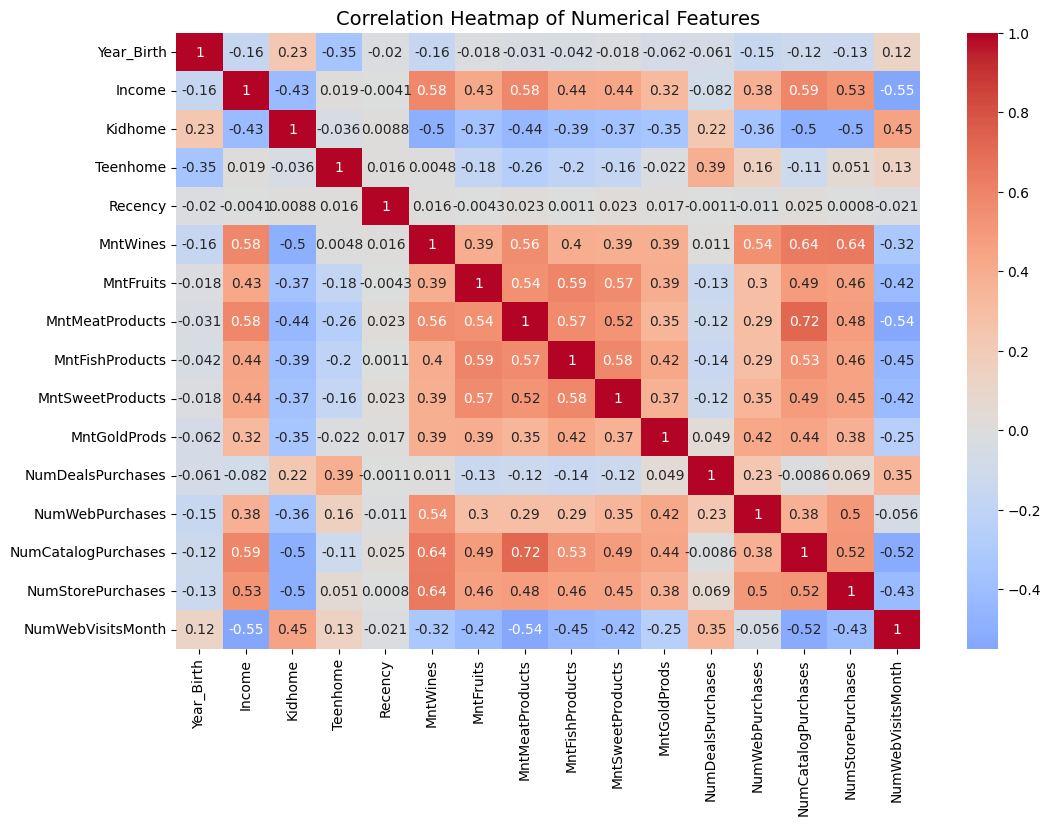

In [105]:
# Correlation heatmap
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True, center=0)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

Understanding Categoricals

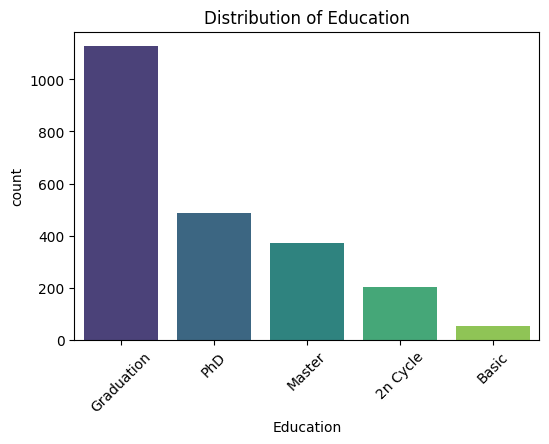

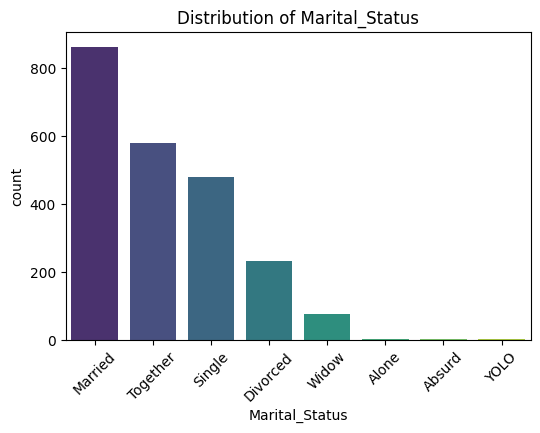

In [106]:
categorical_cols = ["Education", "Marital_Status"]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette="viridis", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

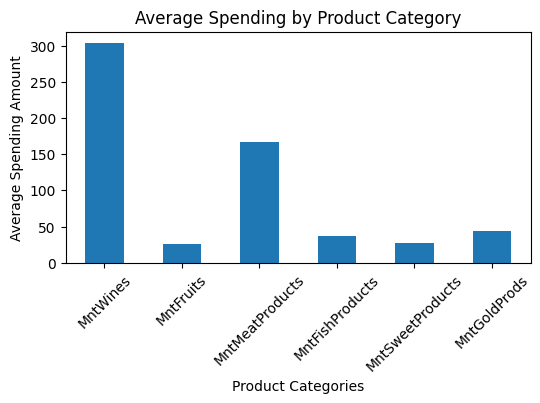

In [192]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Calculate average spending
avg_spending = df[spending_cols].mean()

# Plot bar chart
plt.figure(figsize=(6,3))

avg_spending.plot(kind='bar')

plt.xlabel('Product Categories')
plt.ylabel('Average Spending Amount')
plt.title('Average Spending by Product Category')

plt.xticks(rotation=45)

plt.show()

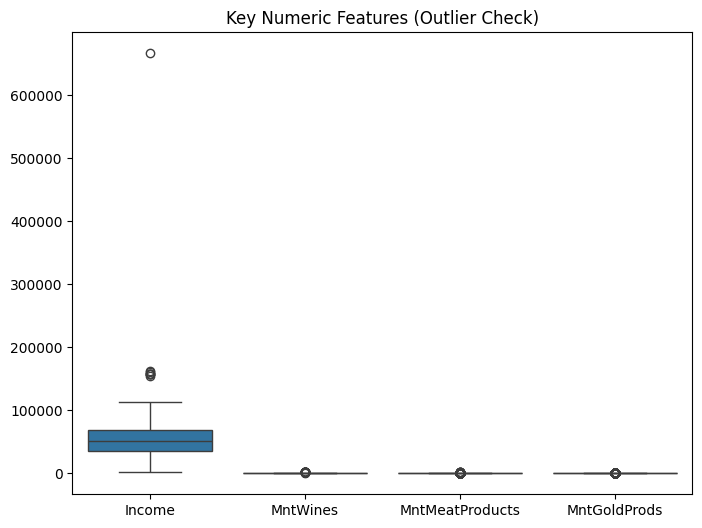

In [193]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[["Income", "MntWines","MntMeatProducts","MntGoldProds"]]) #"MntFishProducts", "MntFruits", "MntSweetProducts"
plt.title("Key Numeric Features (Outlier Check)")
plt.show()

### Aggregate some features

Create Advance features: This should give an overall better performance.

p/s: usually improve segmentation quality significantly.

Benefits include:
- better patterns recognition (a cust can be high in one aspect but overall a low-engaged cust)
- Reduces noise
- Instead of clustering on tiny fragmented behaviors, you give the algorithm summarized customer behavior

In [109]:
df2 = df.copy()

In [114]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [110]:
# Age relative to 2025 (use absolute year for reproducibility)
df2["Age"] = 2025 - df2["Year_Birth"]

In [111]:

# combine children count - Number of young children/teens in the household

df2["Total_kids"] = df2.get("Kidhome", 0) + df2.get("Teenhome", 0)

In [112]:
monetary = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Create Total_Mnt column
df2["Total_Mnt"] = df2[monetary].sum(axis=1)

# View result
print(df2[["Total_Mnt"]].head())

   Total_Mnt
0       1617
1         27
2        776
3         53
4        422


In [115]:
# Number of Purchase - aggregates

purchases = ["NumDealsPurchases", "NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases"]
for c in purchases:
    if c not in df2.columns:
        raise KeyError(f"Expected column '{c}' not found in dataset")

df2["Total_Purchases"] = df2[purchases].sum(axis=1)

In [116]:
# Total Campaign Acceptance

df2['Accepted_Total'] = (
    df2['AcceptedCmp1'] +
   df2['AcceptedCmp2'] +
    df2['AcceptedCmp3'] +
    df2['AcceptedCmp4'] +
    df2['AcceptedCmp5']
)

In [117]:
print(df2[["Accepted_Total"]].head())

   Accepted_Total
0               0
1               0
2               0
3               0
4               0


In [118]:
df2.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Customer_Tenure        0
Age                    0
Total_kids             0
Total_Mnt              0
Total_Purchases        0
Accepted_Total         0
dtype: int64

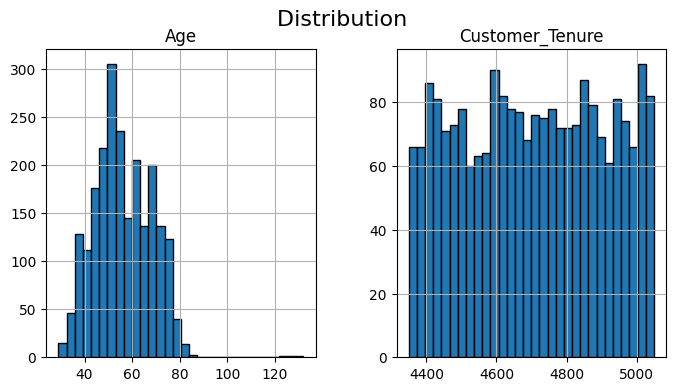

In [119]:
Age_cols = ["Age", "Customer_Tenure"]

# Histograms
df2[Age_cols].hist(figsize=(8, 4), bins=30, edgecolor="black")
plt.suptitle("Distribution ", fontsize=16)
plt.show()

In [120]:
df2[df2['Age'] > 85]['Age'].value_counts().sort_index()

Age
125    1
126    1
132    1
Name: count, dtype: int64

Remove the 3 outliers

In [ ]:
print("Rows before filtering:", df2.shape[0])

# Filter unrealistic ages
df2 = df2[(df2["Age"] <= 100)]


# Reset index
df2 = df2.reset_index(drop=True)
print("Rows after filtering:", df2.shape[0])

Rows before filtering: 2240
Rows after filtering: 2237


Check Engineered Columns

In [125]:
# Engineered columns here
display(df2[["ID","Year_Birth","Age","Income","Total_Mnt","Total_Purchases","Customer_Tenure","Total_kids", "Accepted_Total"]].head())

,ID,Year_Birth,Age,Income,Total_Mnt,Total_Purchases,Customer_Tenure,Total_kids,Accepted_Total
0,5524,1957,68,58138.0,1617,25,5013,0,0
1,2174,1954,71,46344.0,27,6,4463,2,0
2,4141,1965,60,71613.0,776,21,4662,0,0
3,6182,1984,41,26646.0,53,8,4489,1,0
4,5324,1981,44,58293.0,422,19,4511,1,0


View Distribution of Engineered columns

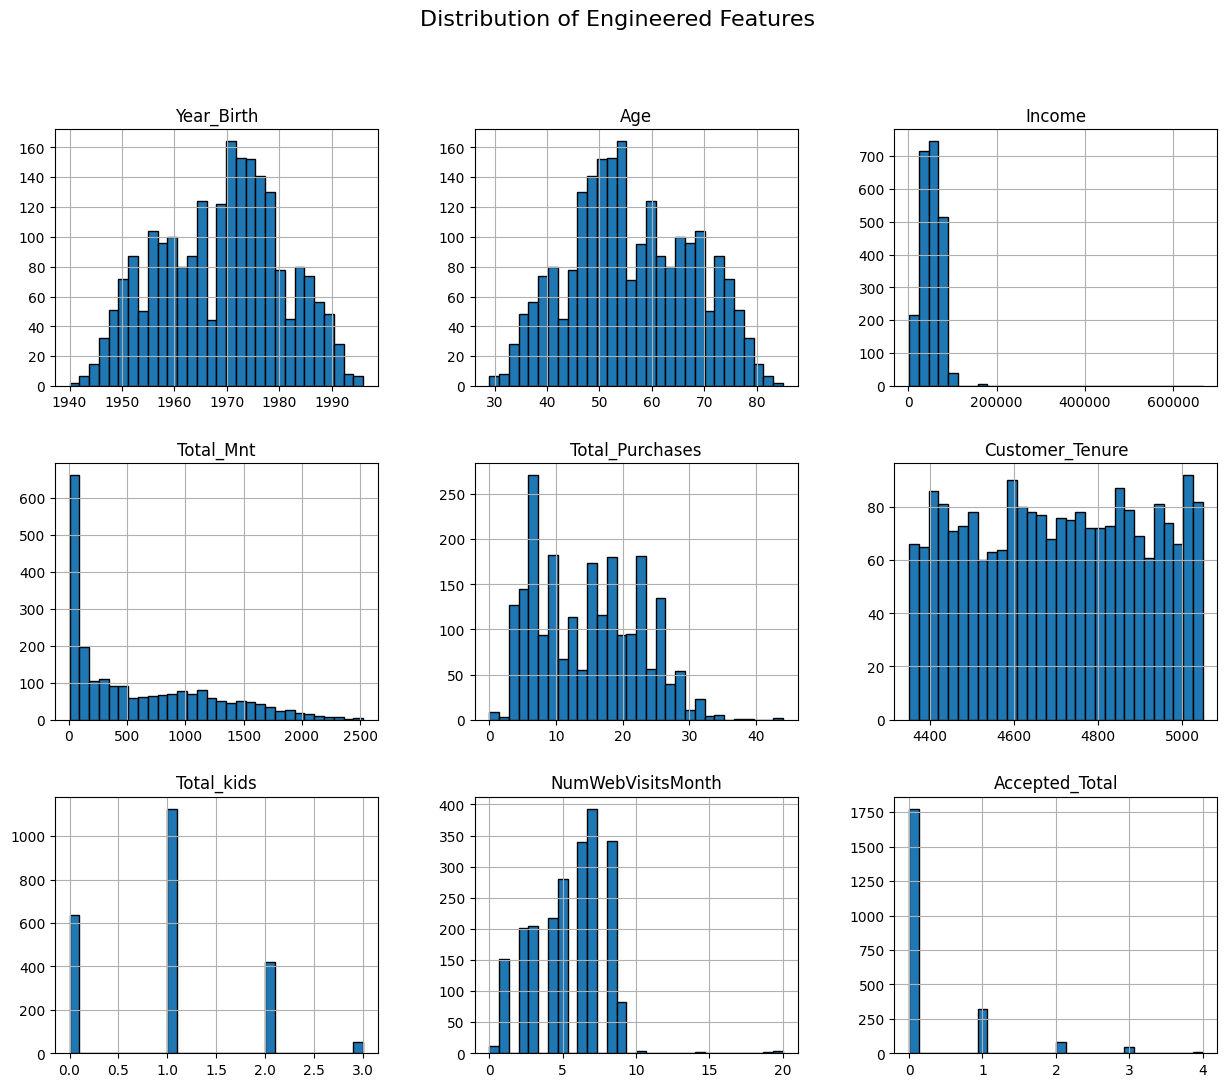

In [127]:
engr_cols = ["Year_Birth", "Age","Income","Total_Mnt","Total_Purchases","Customer_Tenure","Total_kids", "NumWebVisitsMonth", "Accepted_Total"]

# Histograms
df2[engr_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Engineered Features", fontsize=16)
plt.show()

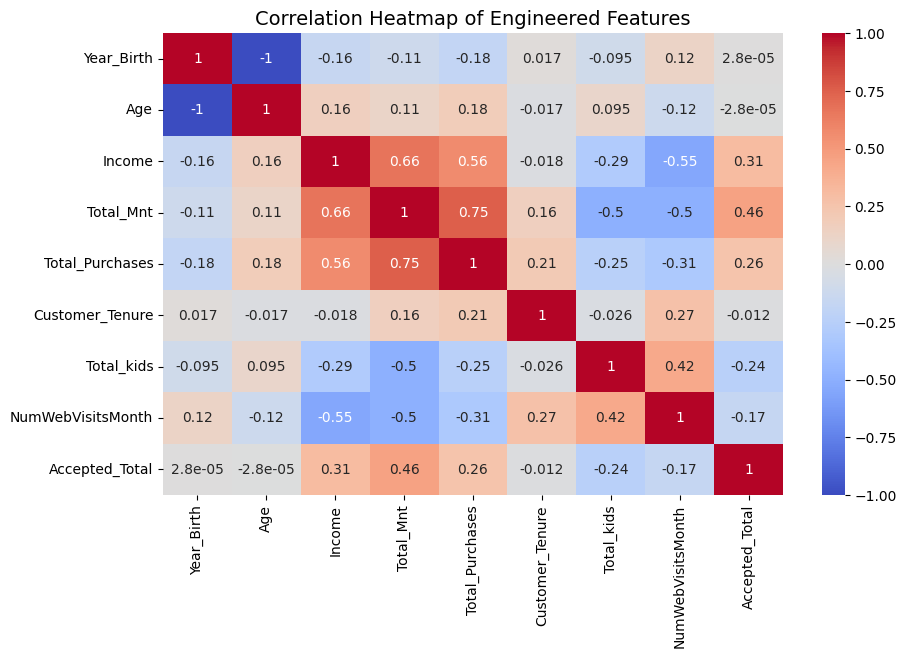

In [ ]:
# Engineered Col - Correlation heatmap
plt.figure(figsize=(10,6))
corr = df2[engr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True, center=0)
plt.title("Correlation Heatmap of Engineered Features", fontsize=14)
plt.show()

'Accepted_Total' and 'Year birth" maybe dropped later.

### Scale the Features

Compare Original VS Engineered features

In [132]:
from sklearn.preprocessing import StandardScaler

features = [
    "Age",
    "Income",
    "Total_Mnt",
    "Total_Purchases",
    "Recency",             # how recent was last purchase
    "NumWebVisitsMonth",   # engagement proxy
    "Total_kids",
    "Customer_Tenure"
    
]

# confirm these columns exist (some datasets vary)
missing = [c for c in features if c not in df2.columns]
if missing:
    raise KeyError(f"Missing expected feature columns: {missing}")

X = df2[features].copy()

# scale for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# keep X and scaler for inverse transform later
print("Features used for clustering:", features)
display(pd.DataFrame(X_scaled, columns=features).head())

Features used for clustering: ['Age', 'Income', 'Total_Mnt', 'Total_Purchases', 'Recency', 'NumWebVisitsMonth', 'Total_kids', 'Customer_Tenure']


,Age,Income,Total_Mnt,Total_Purchases,Recency,NumWebVisitsMonth,Total_kids,Customer_Tenure
0,1.017296,0.236068,1.680649,1.319785,0.307272,0.692882,-1.264618,1.530038
1,1.273722,-0.234982,-0.961838,-1.155824,-0.383584,-0.131574,1.395420,-1.191484
2,0.333495,0.774257,0.282956,0.798604,-0.798098,-0.543802,-1.264618,-0.206788
3,-1.290534,-1.021717,-0.918627,-0.895234,-0.798098,0.280654,0.065401,-1.062830
4,-1.034108,0.242259,-0.305371,0.538014,1.550812,-0.131574,0.065401,-0.953970


In [133]:
from sklearn.preprocessing import StandardScaler

features_original = [
    "Age",
    "Income",
    "Recency",             # how recent was last purchase
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "Total_kids"
    
    
]

# confirm these columns exist (some datasets vary)
missing = [c for c in features_original if c not in df2.columns]
if missing:
    raise KeyError(f"Missing expected feature columns: {missing}")

X_2 = df2[features_original].copy()

# scale for clustering
scaler_2 = StandardScaler()
X_scaled_2 = scaler_2.fit_transform(X_2)

# keep X and scaler for inverse transform later
print("Features used for clustering:", features_original)
display(pd.DataFrame(X_scaled_2, columns=features_original).head())

Features used for clustering: ['Age', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Total_kids']


,Age,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Total_kids
0,1.017296,0.236068,0.307272,0.983671,1.554623,1.680253,2.461700,1.475877,0.846061,0.348371,1.408080,2.510435,-0.552077,0.692882,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-1.264618
1,1.273722,-0.234982,-0.383584,-0.870717,-0.636422,-0.713250,-0.650275,-0.631440,-0.729569,-0.169096,-1.110957,-0.568802,-1.167421,-0.131574,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,1.395420
2,0.333495,0.774257,-0.798098,0.362570,0.572430,-0.176928,1.345050,-0.147000,-0.037829,-0.686563,1.408080,-0.226664,1.293956,-0.543802,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-1.264618
3,-1.290534,-1.021717,-0.798098,-0.870717,-0.560868,-0.651196,-0.503829,-0.582996,-0.748784,-0.169096,-0.751094,-0.910939,-0.552077,0.280654,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,0.065401
4,-1.034108,0.242259,1.550812,-0.389289,0.421324,-0.216820,0.155177,-0.001667,-0.556634,1.383304,0.328493,0.115473,0.063267,-0.131574,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,0.065401


### Elbow (WCSS) and Silhouette diagnostics
 - compute inertia (WCSS) and silhouette scores for k=2..8
 - visualize both plots (two separate plots)
 - WCSS measures how compact clusters are.


In [ ]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# wcss = []

# for k in range(2, 9):
#     kmeans = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init=10
#     )

#     kmeans.fit(X_scaled)
#     wcss.append(kmeans.inertia_)

# plt.figure(figsize=(8,5))
# plt.plot(range(2,9), wcss, marker='o')
# plt.xlabel('Number of Clusters')
# plt.ylabel('WCSS')
# plt.title('Elbow Method')

# plt.show()

In [ ]:
# from sklearn.metrics import silhouette_score

# silhouette_scores = []
# # Test different K values
# for k in range(2, 11):

#     kmeans = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init=10
#     )

#     labels = kmeans.fit_predict(X_scaled)
#     score = silhouette_score(X_scaled, labels)
#     silhouette_scores.append(score)

# # Plot
# plt.figure(figsize=(8,5))
# plt.plot(range(2,11), silhouette_scores, marker='o')
# plt.xlabel('Number of Clusters (K)')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Analysis')

# plt.show()

Elbow (WCSS) and Silhouette diagnostics

OPTION 1: Engineered Features

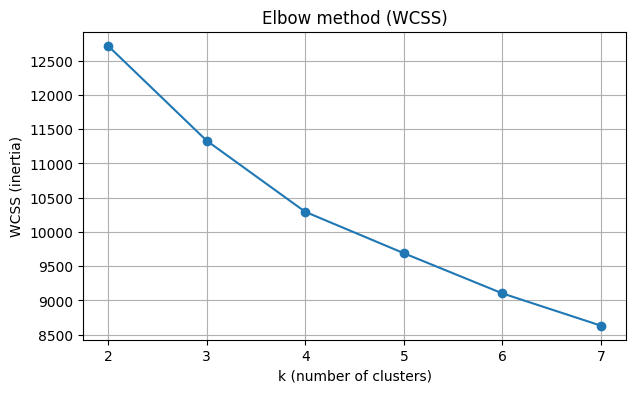

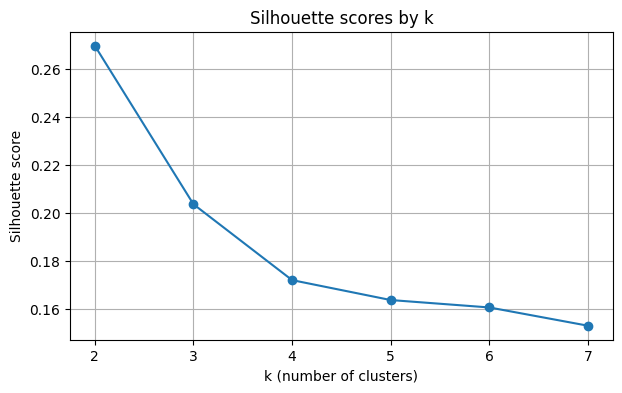

k=2 -> silhouette: 0.2698
k=3 -> silhouette: 0.2037
k=4 -> silhouette: 0.1721
k=5 -> silhouette: 0.1638
k=6 -> silhouette: 0.1607
k=7 -> silhouette: 0.1531


In [ ]:
# Elbow (WCSS) and Silhouette diagnostics
# - compute inertia (WCSS) and silhouette scores for k=2..8
# - visualize both plots (two separate plots)


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = list(range(2, 8))
wcss = []
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

# Plot WCSS (Elbow)
plt.figure(figsize=(7,4))
plt.plot(Ks, wcss, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("WCSS (inertia)")
plt.title("Elbow method (WCSS)")
plt.grid(True)
plt.show()

# Plot silhouette
plt.figure(figsize=(7,4))
plt.plot(Ks, sil_scores, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores by k")
plt.grid(True)
plt.show()

# Print values
for k, s in zip(Ks, sil_scores):
    print(f"k={k} -> silhouette: {s:.4f}")

k=2 looks like the best cluster so far

Elbow (WCSS) and Silhouette diagnostics

OPTION 2: Original Features

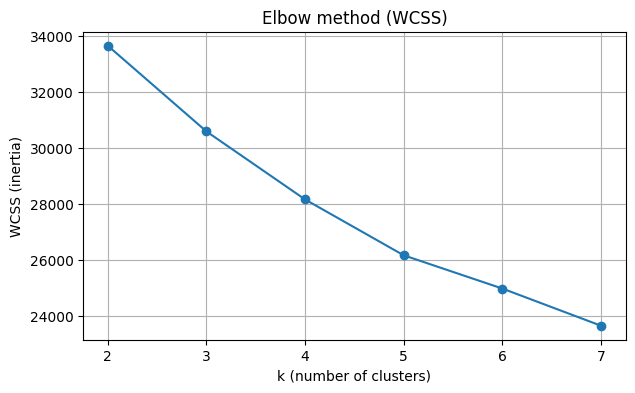

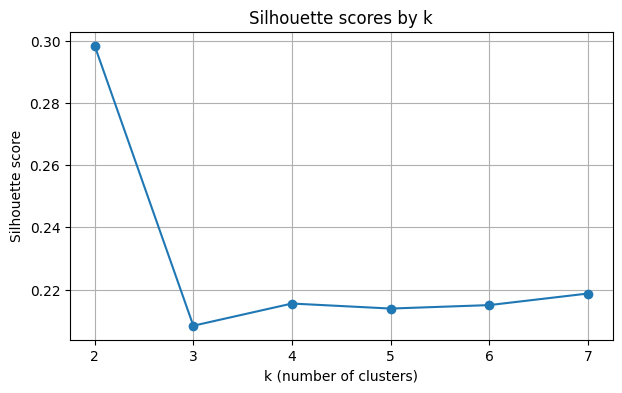

k=2 -> silhouette: 0.2984
k=3 -> silhouette: 0.2084
k=4 -> silhouette: 0.2155
k=5 -> silhouette: 0.2139
k=6 -> silhouette: 0.2150
k=7 -> silhouette: 0.2187


In [145]:
Ks = list(range(2, 8))
wcss = []
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled_2)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_2, lbl))

# Plot WCSS (Elbow)
plt.figure(figsize=(7,4))
plt.plot(Ks, wcss, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("WCSS (inertia)")
plt.title("Elbow method (WCSS)")
plt.grid(True)
plt.show()

# Plot silhouette
plt.figure(figsize=(7,4))
plt.plot(Ks, sil_scores, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores by k")
plt.grid(True)
plt.show()

# Print values
for k, s in zip(Ks, sil_scores):
    print(f"k={k} -> silhouette: {s:.4f}")

In [155]:
from sklearn.mixture import GaussianMixture

best_k = Ks[np.argmax(sil_scores)] # highest silhouette score
print("Automatically selected best_k (by silhouette):", best_k)

# Fit KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
klabels = kmeans.fit_predict(X_scaled)

# Optionally fit GMM for soft clustering / comparison
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# attach labels to df2
df2["KMeansCluster"] = klabels
df2["GMMCluster"] = gmm_labels

print("Cluster counts (KMeans):")
print(df2["KMeansCluster"].value_counts().sort_index())

Automatically selected best_k (by silhouette): 2
Cluster counts (KMeans):
KMeansCluster
0    1253
1     984
Name: count, dtype: int64


Engineered features Results were:

KMeansCluster
0    1390
1     847

In [ ]:
#Create Cluster Summary Table

cluster_summary = df2.groupby("KMeansCluster")[engr_cols].agg(["mean"])

print(cluster_summary.T)

KMeansCluster                      0             1
Year_Birth        mean   1970.652035   1966.672764
Age               mean     54.347965     58.327236
Income            mean  37200.248204  71362.601626
Total_Mnt         mean    160.033520   1173.298780
Total_Purchases   mean      9.740623     21.403455
Customer_Tenure   mean   4688.322426   4723.486789
Total_kids        mean      1.270551      0.543699
NumWebVisitsMonth mean      6.537111      3.768293
Accepted_Total    mean      0.106943      0.540650


- Which cluster spends the most: CLUSTER 1
- Which cluster spends more: CLUSTER 1 
- Which cluster earns more: CLUSTER 1
- Which cluster visits website frequently: CLUSTER 0
- Which cluster purchases the least: CLUSTER 0

CLUSTER 1: High-Value Customers

CLUSTER 0: Low Engagement Customers



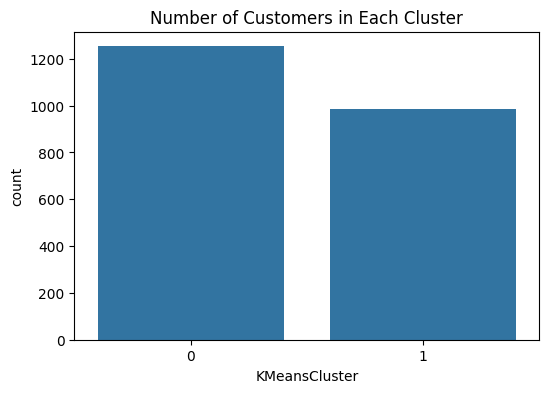

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x='KMeansCluster',
    data=df2
)

plt.title('Number of Customers in Each Cluster')

plt.show()

Average Spending Per Cluster

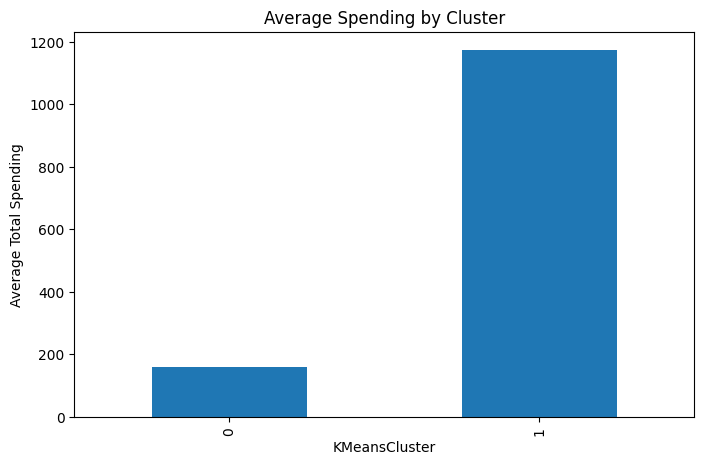

In [164]:
cluster_spending = df2.groupby('KMeansCluster')['Total_Mnt'].mean()

cluster_spending.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Average Total Spending')
plt.title('Average Spending by Cluster')

plt.show()

In [166]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df2['PCA1'] = X_pca[:,0]
df2['PCA2'] = X_pca[:,1]

### PCA Scatterplot Visualization

Cluster Size

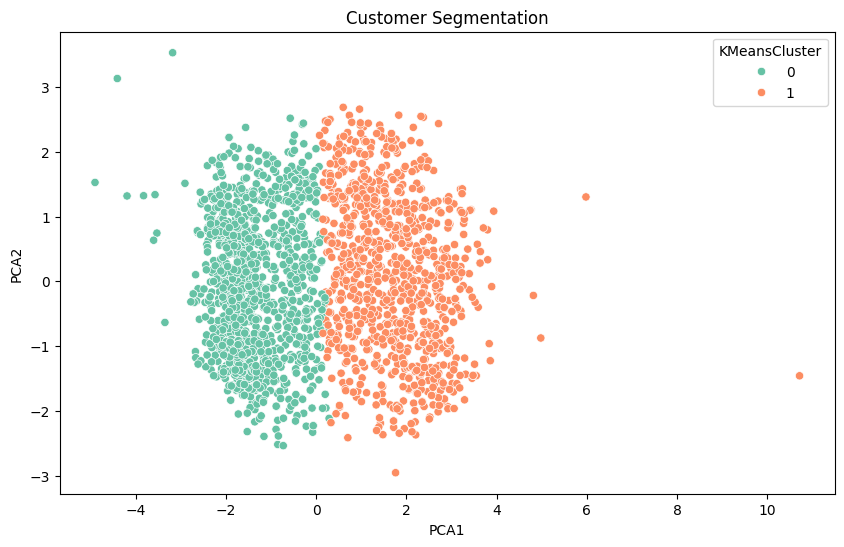

In [169]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='KMeansCluster',
    data=df2,
    palette='Set2'
)

plt.title('Customer Segmentation')

plt.show()

There is visible seperation and 2 distinct groups

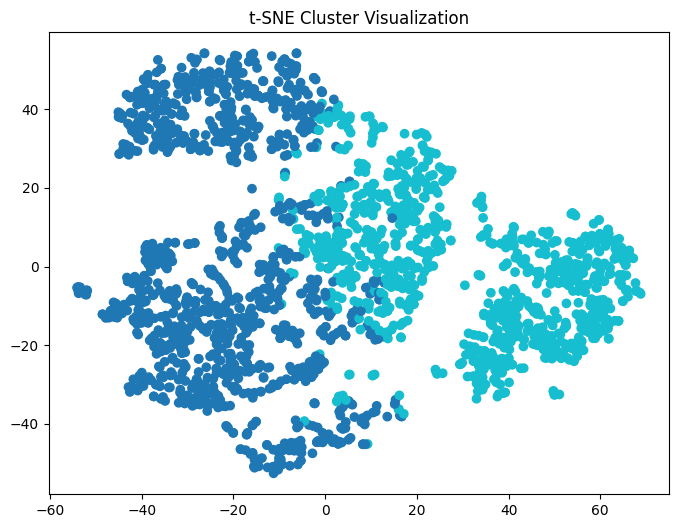

In [ ]:
#TSNE Plot

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df2['KMeansCluster'],
    cmap='tab10'
)

plt.title("t-SNE Cluster Visualization")
plt.show()

In [177]:
from sklearn.metrics import calinski_harabasz_score

score = calinski_harabasz_score(X_scaled, klabels)

print(score)

909.3428301990015


Gaussian Mixture Model (GMM)

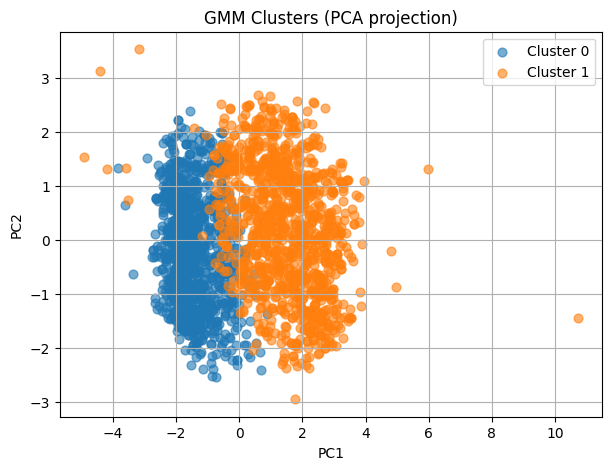

In [ ]:
# Gaussian Mixture Model (GMM) + visualization
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=best_k, random_state=42)
glabels = gmm.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
for c in np.unique(glabels):
    plt.scatter(X_pca[glabels==c,0], X_pca[glabels==c,1], label=f"Cluster {c}", s=40, alpha=0.6)
plt.title("GMM Clusters (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.grid(True)
plt.show()

groups are almost clearly separated

DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

# Fit model
labels = dbscan.fit_predict(X_scaled)

# Noise/outliers will be labeled -1

df2['DBSCAN_Cluster'] = labels

In [181]:
print(df2['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 2    1076
 1     392
 0     382
-1     293
 3      74
 5       8
 6       7
 4       5
Name: count, dtype: int64


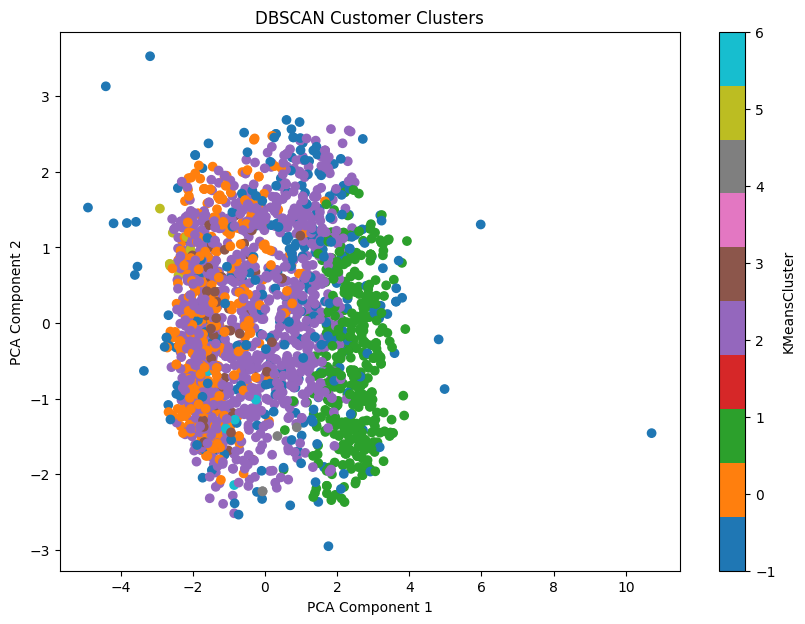

In [182]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create plot
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df2['DBSCAN_Cluster'],
    cmap='tab10'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Customer Clusters')

plt.colorbar(scatter, label='KMeansCluster')

plt.show()

In [184]:
n_clusters = len(set(klabels)) - (1 if -1 in klabels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 2


Hierarchical clustering

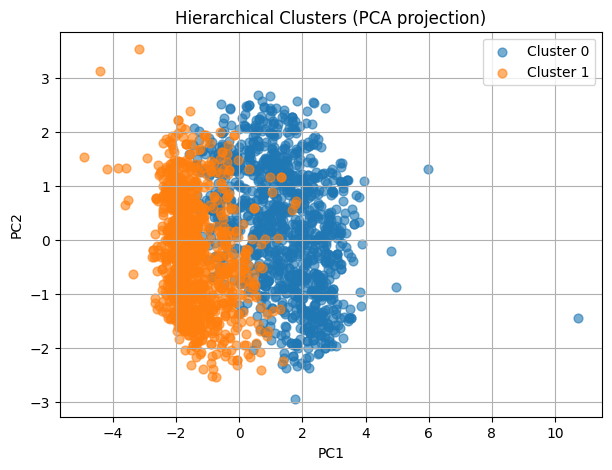

In [ ]:
# Agglomerative Hierarchical clustering + visualization
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
alabels = agg.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
for c in np.unique(alabels):
    plt.scatter(X_pca[alabels==c,0], X_pca[alabels==c,1], label=f"Cluster {c}", s=40, alpha=0.6)
plt.title("Hierarchical Clusters (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.grid(True)
plt.show()

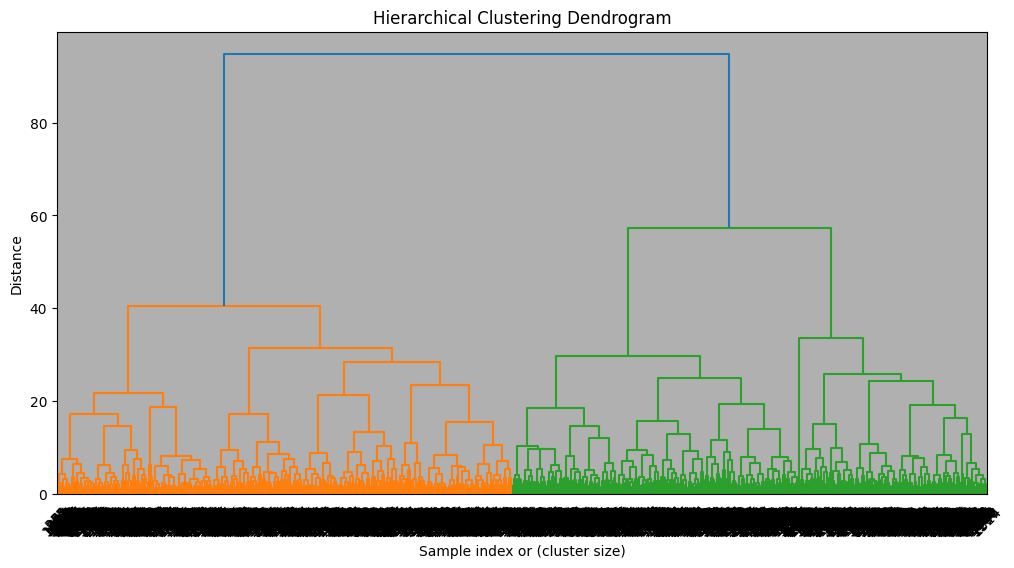

In [ ]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12,6))
linkage_matrix = sch.linkage(X_scaled, method="ward")

# dendrogram plot
dendro = sch.dendrogram(
    linkage_matrix,
    truncate_mode="level",   # show only top levels (cleaner)
    p=20,                    # number of leaf nodes shown
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN

results = {}

# --- KMeans ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
kmeans_labels = kmeans.fit_predict(X_scaled)
results["KMeans"] = [
    silhouette_score(X_scaled, kmeans_labels),
    davies_bouldin_score(X_scaled, kmeans_labels),
    calinski_harabasz_score(X_scaled, kmeans_labels)
]

# --- GMM ---
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
results["GMM"] = [
    silhouette_score(X_scaled, gmm_labels),
    davies_bouldin_score(X_scaled, gmm_labels),
    calinski_harabasz_score(X_scaled, gmm_labels)
]

# --- DBSCAN ---
dbscan = DBSCAN(eps=1.8, min_samples=8)  # tweak eps if needed
dbscan_labels = dbscan.fit_predict(X_scaled)

# DBSCAN sometimes assigns all points to -1 (noise), so check
if len(set(dbscan_labels)) > 1 and len(set(dbscan_labels)) < len(X_scaled):
    results["DBSCAN"] = [
        silhouette_score(X_scaled, dbscan_labels),
        davies_bouldin_score(X_scaled, dbscan_labels),
        calinski_harabasz_score(X_scaled, dbscan_labels)
    ]
else:
    results["DBSCAN"] = ["Invalid", "Invalid", "Invalid"]

# --- Hierarchical ---
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
results["Hierarchical"] = [
    silhouette_score(X_scaled, agg_labels),
    davies_bouldin_score(X_scaled, agg_labels),
    calinski_harabasz_score(X_scaled, agg_labels)
]

# --- Show results ---
# Silhouette Score: Measures how separated clusters are from other clusters >
# Davies–Bouldin Index: Measures overlap between clusters <
# Calinski–Harabasz Score: measures cluster separation >
metrics = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
results_df = pd.DataFrame(results, index=metrics).T
display(results_df)

,Silhouette,Davies-Bouldin,Calinski-Harabasz
KMeans,0.269780,1.484550,909.342830
GMM,0.249174,1.562116,816.401138
DBSCAN,0.435873,5.008376,9.337462
Hierarchical,0.230563,1.629400,750.692059


### Interpretation

Kmeans: has the strongest cluster structure.
- acceptable silhouette
- highest CH score
- good DBI


GMM: Very close to KMeans but slightly weaker across all metrics.
- slightly more overlap

Hierarchical:
- lower silhouette
- higher DBI
- lower CH

DBSCAN: Discard this one - weak overall.



### Recommendation

KMeans is probably the best choice. Overall better numbers. strongest overall cluster structure. K-Means achieved the best balance across all evaluation metrics, suggesting more meaningful and stable customer segments suitable for business interpretation.



